## Multiagent Workflow with LangGraph: An Interactive Notebook

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Set the environment variable for the Groq API key
import os
os.environ['GROQ_API_KEY']=os.getenv("GROQ_API_KEY")

# Import the necessary model from langchain_groq
from langchain_groq import ChatGroq
model = ChatGroq(model_name="deepseek-r1-distill-llama-70b", temperature=0.1)

# from langchain_google_genai import ChatGoogleGenerativeAI
# model=ChatGoogleGenerativeAI(model="gemini-1.5-flash")

output=model.invoke("Do you know about kolhapur?")
print(output.content)

# import embedding model (huggingface or google genai)
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
# from langchain_google_genai import GoogleGenerativeAIEmbeddings
# embeddings = GoogleGenerativeAIEmbeddings(model="gemini-1.5-flash")

# Use the embeddings model to embed a text
text = "Do you know about kolhapur?"
embedded_text = embeddings.embed_query(text)
print(embedded_text)

<think>

</think>

Yes, Kolhapur is a city in the Indian state of Maharashtra. It is known for its rich cultural heritage, historical sites, and traditional arts. Here are some key points about Kolhapur:

1. **Historical Significance**: Kolhapur has a long history dating back to the ancient period. It was once the capital of the Maratha Empire under the rule of Chhatrapati Shivaji Maharaj.

2. **Mahalaxmi Temple**: The city is famous for the Mahalaxmi Temple, a prominent Hindu temple dedicated to Goddess Mahalaxmi (an incarnation of Goddess Durga). It is one of the most visited temples in Maharashtra.

3. **Kolhapuri Chappals**: Kolhapur is renowned for its traditional leather sandals known as Kolhapuri Chappals, which are popular across India.

4. **Cuisine**: Kolhapur is known for its spicy cuisine, including dishes like Kolhapuri Misal, Kolhapuri Tambda Rassa, and Kolhapuri Sukka Mutton.

5. **Agriculture**: The region is agriculturally rich, with sugarcane being a major crop. Kolha

c:\Users\niles\Agentic-AI2.0\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[-0.00012399062688928097, 0.06594432145357132, -0.05696497857570648, 0.11082831025123596, -0.09879505634307861, 0.010566853918135166, -0.023451145738363266, -0.09554963558912277, -0.05485067516565323, -0.028970154002308846, -0.010063259862363338, -0.08084593713283539, 0.058327171951532364, -0.004875759594142437, 0.010874181054532528, -0.01570434495806694, -0.009349220432341099, -0.01952083595097065, -0.017214573919773102, -0.09035691618919373, -0.023660529404878616, -0.02476320043206215, 0.007049539126455784, 0.00940292701125145, -0.016765564680099487, -0.04853079095482826, 0.005604990292340517, -0.030824683606624603, -0.045019786804914474, -0.035743921995162964, 0.006386153399944305, 0.1041908785700798, 0.009543201886117458, -0.04400252178311348, 0.012843159027397633, 0.07956233620643616, 0.016574954614043236, 0.03960588201880455, 0.06861216574907303, 0.03334010764956474, 0.014811807312071323, 0.03799363225698471, 0.032121140509843826, -0.052506592124700546, -0.01130905281752348, -0.0

### Creating one dummy multiagent

In [3]:
from langchain_core.tools import tool
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

# Bind the tools to the model
llm_with_tool=model.bind_tools([transfer_to_addition_expert])

# Invoke the model with a message
response=llm_with_tool.invoke("hi")
print(response.content)
print(response.tool_calls)

# Invoke the model with another message
response=llm_with_tool.invoke("what is 2+2?")
print(response.content)
print(response.tool_calls)

# Define a system prompt and messages for the model
system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
messages = [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]
messages

Hello! How can I assist you with addition today? What numbers would you like to add?
[]

[{'name': 'transfer_to_addition_expert', 'args': {}, 'id': 'stajm363j', 'type': 'tool_call'}]


[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [4]:
from typing_extensions import Literal
from langgraph.graph import MessagesState,StateGraph, START,END
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent


def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}



## Agent


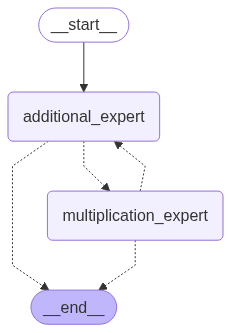

In [5]:
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = model.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}
graph=StateGraph(MessagesState)
graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)
graph.add_edge(START, "additional_expert")
app=graph.compile()

# Visualize the workflow using Mermaid
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [6]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='fa7e7b69-2ae4-48d3-91e1-0eba46c52ca9'),
  AIMessage(content='The result of (3 + 5) * 12 is 96.\n\nStep-by-step explanation:\n1. Calculate the addition inside the parentheses: 3 + 5 = 8.\n2. Multiply the result by 12: 8 * 12 = 96.\n\nAnswer: 96', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 219, 'prompt_tokens': 160, 'total_tokens': 379, 'completion_time': 0.796363636, 'prompt_time': 0.01643744, 'queue_time': 0.057241493000000004, 'total_time': 0.812801076}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--d45245f9-0b68-46da-861d-4acdeb331d0d-0', usage_metadata={'input_tokens': 160, 'output_tokens': 219, 'total_tokens': 379})]}

## With realtime tool

In [7]:
from langchain_community.tools import DuckDuckGoSearchRun
# search_tool=DuckDuckGoSearchRun()

import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)
search_tool.invoke("who is a current pm of uk?")

[{'title': 'List of prime ministers of the United Kingdom - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/List_of_prime_ministers_of_the_United_Kingdom',
  'content': 'The current prime minister is Keir Starmer, who assumed the office on 5 July 2024. ... This page was last edited on 6 July 2025, at 22:10 (UTC). Content is',
  'score': 0.8652358},
 {'title': 'Prime Minister - GOV.UK',
  'url': 'https://www.gov.uk/government/ministers/prime-minister',
  'content': 'The Prime Minister is the leader of His Majesty’s Government and is ultimately responsible for the policy and decisions of the government.\n\nAs leader of the UK government the Prime Minister also:\n\n## Current role holder\n\n### The Rt Hon Sir Keir Starmer KCB KC MP\n\nSir Keir Starmer became Prime Minister on 5 July 2024.\n\n## Education [...] Keir attended Reigate Grammar School, before studying Law at the University of Leeds. He went on to do postgraduate studies at the University of Oxford, receiving a Bachelor of 

In [8]:
from langchain_experimental.utilities import PythonREPL
repl=PythonREPL()
code = """
x = 5
y = x * 2
print(y)
"""
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [9]:
from typing import Annotated
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )
    
python_repl_tool

<>:14: SyntaxWarning: invalid escape sequence '\`'
<>:14: SyntaxWarning: invalid escape sequence '\`'
<>:14: SyntaxWarning: invalid escape sequence '\`'
<>:14: SyntaxWarning: invalid escape sequence '\`'
C:\Users\niles\AppData\Local\Temp\ipykernel_25324\3756490519.py:14: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\niles\AppData\Local\Temp\ipykernel_25324\3756490519.py:14: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


StructuredTool(name='python_repl_tool', description='Use this to execute python code. If you want to see the output of a value,\nyou should print it out with `print(...)`. This is visible to the user.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x000001BC932E5A80>)

In [10]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [11]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [12]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )
make_system_prompt("You can only do research. You are working with a chart generator colleague.")

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [13]:
from langchain_core.messages import BaseMessage, HumanMessage
def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

## agent1

In [14]:
def research_node(state:MessagesState)->Command[Literal["chart_generator", END]]:
    research_agent=create_react_agent(
        model,
        tools=[search_tool],
        prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ), 
        )
    
    
    
    result=research_agent.invoke(state)
    
    goto=get_next_node(result["messages"][-1],"chart_generator")
    
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    
    return Command(update={"messages": result["messages"]},goto=goto)


In [15]:
# agent1(human1)-->agent2(human2)

## agent2

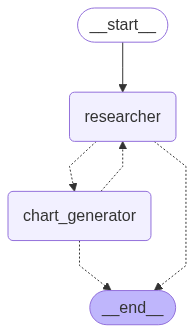

In [16]:
import matplotlib.pyplot as plt
def chart_node(state:MessagesState)-> Command[Literal["researcher", END]]:
    chart_agent=create_react_agent(
        model,
        tools=[python_repl_tool],
        prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
        )
    result=chart_agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    return Command(update={"messages": result["messages"]},goto=goto)

# Define the workflow using StateGraph
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()
workflow.compile()

In [17]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})

{'messages': [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='a316da48-af01-4d8b-a78a-727ee76bc816'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't94t6w4qa', 'function': {'arguments': '{"query":"UK GDP past three years 2021 2022 2023"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 557, 'prompt_tokens': 287, 'total_tokens': 844, 'completion_time': 2.1847814469999998, 'prompt_time': 0.018352453, 'queue_time': 0.069011587, 'total_time': 2.2031339}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a85e8f48-d975-4633-ace1-8cdc66760d03-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'UK GDP past three years 2021 2022 2023'}, 'id': 't94t6w4qa', 'type': 'to

In [18]:
code="""import matplotlib.pyplot as plt\\n\\n# Data for the UK GDP over the past 3 years\\nyears = [2019, 2020, 2021]\\ngdp_values = [2851.41, 2697.81, 3141.51]  # in billion $ \\n\\ndef create_line_chart(years, gdp_values):\\n    plt.figure(figsize=(10, 6))\\n    plt.plot(years, gdp_values, marker=\'o\', color=\'b\', linestyle=\'-\', linewidth=2)\\n    plt.title(\'UK GDP Over the Past 3 Years\')\\n    plt.xlabel(\'Year\')\\n    plt.ylabel(\'GDP (in billion $)\')\\n    plt.grid(True)\\n    plt.tight_layout()\\n    plt.show()"""
print(code)

import matplotlib.pyplot as plt\n\n# Data for the UK GDP over the past 3 years\nyears = [2019, 2020, 2021]\ngdp_values = [2851.41, 2697.81, 3141.51]  # in billion $ \n\ndef create_line_chart(years, gdp_values):\n    plt.figure(figsize=(10, 6))\n    plt.plot(years, gdp_values, marker='o', color='b', linestyle='-', linewidth=2)\n    plt.title('UK GDP Over the Past 3 Years')\n    plt.xlabel('Year')\n    plt.ylabel('GDP (in billion $)')\n    plt.grid(True)\n    plt.tight_layout()\n    plt.show()
